# Sentiment Analysis using Machine Learning (NLP)

## Goal: Classify movie reviews as Positive or Negative

In [1]:
import pandas as pd

In [2]:
#Importing Dataset
df=pd.read_csv("IMDB Dataset.csv")
pd.set_option('display.max_colwidth',None)
df = df[['sentiment', 'review']]
df=df.head(2000)
df.head()

,sentiment,review
0,positive,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
1,positive,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done."
2,positive,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends."
3,negative,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kil

### Removal of HTML Tags

In [3]:
df['review']=df['review'].str.replace(r'<br\s*/?>',' ',regex=True)
df.head()

,sentiment,review
0,positive,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
1,positive,"A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done."
2,positive,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love. This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her ""sexy"" image and jumped right into a average, but spirited young woman. This may not be the crown jewel of his career, but it was wittier than ""Devil Wears Prada"" and more interesting than ""Superman"" a great comedy to go see with friends."
3,negative,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time. This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie. OK, first of all when you're going to make a film you must Decide if its a thriller or a

In [4]:
#Exploring Data
df.shape

(2000, 2)

In [5]:
#checking the no.of distinct values in sentiment
df['sentiment'].value_counts()

sentiment
positive    1005
negative     995
Name: count, dtype: int64

In [6]:
#information of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentiment  2000 non-null   str  
 1   review     2000 non-null   str  
dtypes: str(2)
memory usage: 31.4 KB


In [7]:
#checking for null values
df.isnull().sum()

sentiment    0
review       0
dtype: int64

In [8]:
#checking for dupliacate values
df.duplicated().sum()

np.int64(0)

In [9]:
#Dropping the dupicate values
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Data Analysis

<Axes: ylabel='sentiment'>

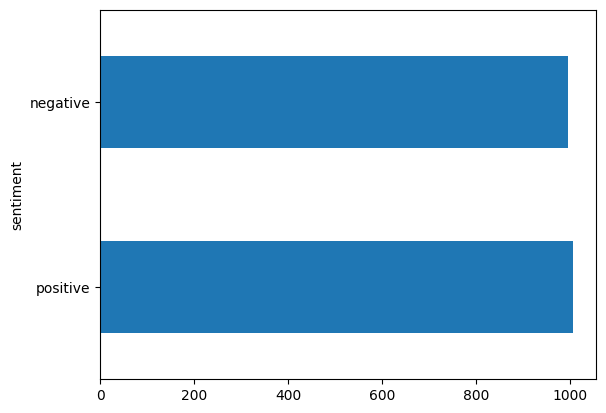

In [10]:
df['sentiment'].value_counts().plot(kind='barh')

In [11]:
# ClASSES ARE BALANCED

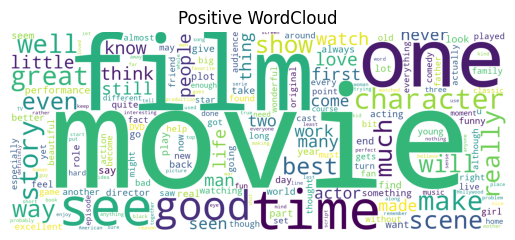

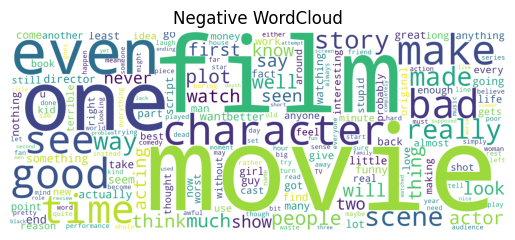

In [12]:
#Showing positive and negative most used words
from wordcloud import WordCloud
import matplotlib.pyplot as plt
positive_reviews=' '.join(df[df['sentiment']=='positive']['review'])
negative_reviews=' '.join(df[df['sentiment']=='negative']['review'])
#creating positive word cloud
positive_word_cloud=WordCloud(background_color='white',width=2500,height=1000)
positive_word_cloud.generate(positive_reviews)
#creating negative cloud
negative_word_cloud=WordCloud(background_color='white',width=2500,height=1000)
negative_word_cloud.generate(negative_reviews)
#Plot Positive WordCloud
plt.imshow(positive_word_cloud)
plt.axis('off')
plt.title("Positive WordCloud")
plt.show()
#Plot Negative WordCloud
plt.imshow(negative_word_cloud)
plt.axis('off')
plt.title("Negative WordCloud")
plt.show()

# Text PreProcessing

In [13]:
#function to clean text
import re
def preprocessing(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text=text.lower()    
    text=re.sub(r'[^\s\w]',' ',text)
    text=re.sub(r'[\d+]',' ',text)
    return text

In [14]:
#apply for the dataset
df['review']=df['review'].apply(preprocessing)

In [15]:
#importing libraries for tokenization,lemmatization,removal of stopwords
import spacy
nlp=spacy.load('en_core_web_sm')

In [16]:
# function for tokenization,lemmatization,removal of stopwords
def token_lemma_nonstop(text):
    doc=nlp(text)
    output=[token.lemma_ for token in doc if not token.is_stop]
    output=' '.join(output)
    output=re.sub(r'\s+',' ',output)
    return output

In [17]:
#applying on dataset
df['text_cleaned']=df['review'].apply(token_lemma_nonstop)

In [18]:
df.head(2)

,sentiment,review,text_cleaned
0,positive,one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to many aryans muslims gangstas latinos christians italians irish and more so scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldn t dare forget pretty pictures painted for mainstream audiences forget charm forget romance oz doesn t mess around the first episode i ever saw struck me as so nasty it was surreal i couldn t say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards who ll be sold out for a nickel inmates who ll kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewing thats if you can get in touch with your darker side,reviewer mention watch oz episode ll hook right exactly happen thing strike oz brutality unflinche scene violence set right word trust faint hearted timid pull punch regard drug sex violence hardcore classic use word call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inward privacy high agenda em city home aryan muslims gangsta latinos christians italian irish scuffle death stare dodgy dealing shady agreement far away main appeal fact go show wouldn t dare forget pretty picture paint mainstream audience forget charm forget romance oz doesn t mess episode see strike nasty surreal couldn t ready watch develop taste oz get accustomed high level graphic violence violence injustice crook guard ll sell nickel inmate ll kill order away mannered middle class inmate turn prison bitch lack street skill prison experience watch oz comfortable uncomfortable view s touch dark
1,positive,a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great master s of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwell s murals decorating every surface are terribly well done,wonderful little production filming technique unassuming old time bbc fashion give comforting discomforte sense realism entire piece actor extremely choose michael sheen get polari voice pat truly seamless editing guide reference williams diary entry worth watching terrificly write perform piece masterful production great master s comedy life realism come home li

In [19]:
#Function for Cleaning and Normalizing
def clean_and_normalize(text):
    output=preprocessing(text)
    output=token_lemma_nonstop(output)
    return output

# Vectorization

In [20]:
#imporing Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(stop_words='english',ngram_range=(1,2),min_df=2)
text=df['text_cleaned']
dtm=tf.fit_transform(text)
dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 194172 stored elements and shape (2000, 23978)>

In [21]:
#converting data matrix to DataFrame
xt_df=pd.DataFrame(dtm.toarray(),columns=tf.get_feature_names_out())
xt_df

,aaron,abandon,abbey,abbot,abbott,abbott costello,abbreviate,abduct,abduct little,abe,...,zombie film,zombie genre,zombie look,zombie movie,zone,zoo,zoom,zu,zu warrior,zucker
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Take y as Sentiment (Output)
y=df['sentiment']
y.head()

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str

In [ ]:
#Funstion for Vectorization
def vectorizer(text):
    dt=tf.transform([text])
    x_vectored=pd.DataFrame(dt.toarray(),columns=tf.get_feature_names_out())
    return x_vectored

# Training the Models

In [24]:
#Importing all Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler

## Comparing All Models

### Logistic Regression

In [25]:
model_lr=LogisticRegression(C=1.0)
xl_train,xl_test,yl_train,yl_test=train_test_split(xt_df,y,test_size=0.2,random_state=42)
model_lr.fit(xl_train,yl_train)
yl_pred=model_lr.predict(xl_test)
accuracy_score(yl_test,yl_pred)

0.8425

# Naive Bayes

In [26]:
model_nb=MultinomialNB()
xnb_train,xnb_test,ynb_train,ynb_test=train_test_split(xt_df,y,test_size=0.2,random_state=42)
model_nb.fit(xnb_train,ynb_train)
ynb_pred=model_nb.predict(xnb_test)
accuracy_score(ynb_test,ynb_pred)

0.8375

# SVM

In [28]:
xs_train,xs_test,ys_train,ys_test=train_test_split(xt_df,y,test_size=0.2,random_state=42)
model_svm=SVC(kernel='linear',C=1.0)
model_svm=model_svm.fit(xs_train,ys_train)
ys_pred=model_svm.predict(xs_test)

In [29]:
accuracy_score(ys_test,ys_pred)

0.85

# Decision Tree Classifier

In [31]:
model_d=DecisionTreeClassifier(criterion='entropy')
xd_train,xd_test,yd_train,yd_test=train_test_split(xt_df,y,test_size=0.2,random_state=42)
model_d.fit(xd_train,yd_train)
yd_pred=model_d.predict(xd_test)
accuracy_score(yd_test,yd_pred)

0.7275

# Random Forest Classifier

In [33]:
model_r=RandomForestClassifier(n_estimators=100,random_state=42)
xr_train,xr_test,yr_train,yr_test=train_test_split(xt_df,y,test_size=0.2,random_state=42)
model_r.fit(xr_train,yr_train)
yr_pred=model_r.predict(xr_test)
accuracy_score(yr_test,yr_pred)

0.835

#### As SVM has more accuracy we SVM as our model

In [34]:
final_model=model_svm

In [42]:
#accuarcy score
accuracy_score(ys_test,ys_pred)

0.85

In [39]:
#confusion matrix
print(classification_report(ys_test,ys_pred))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.84       195
    positive       0.85      0.86      0.86       205

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



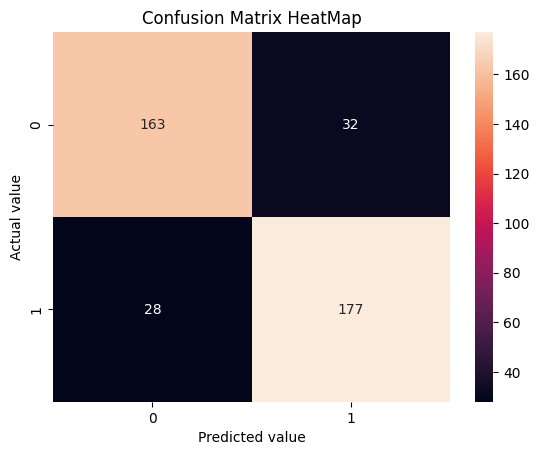

In [48]:
#Heat Map representation for confusion Matrix
import seaborn as sns
cm=confusion_matrix(ys_test,ys_pred)
cm
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title("Confusion Matrix HeatMap")
plt.show()

In [ ]:
#Function for Sentiment Analysis
def sentiment_analysis(text):
    clean_text=clean_and_normalize(text)
    vectored=vectorizer(clean_text)
    output=final_model.predict(vectored)[0]
    return output

# Testing on Unseen Data

In [84]:
pred_sen1="The movie is good!"
pred_sen2="Worst movie ever"

In [85]:
sentiment_analysis(pred_sen1)

'positive'

In [63]:
sentiment_analysis(pred_sen2)

'negative'

In [66]:
sen3='I saw this film on September 1st, 2005 in Indianapolis. I am one of the judges for the Heartland Film Festival that screens films for their Truly Moving Picture Award. A Truly Moving Picture "...explores the human journey by artistically expressing hope and respect for the positive values of life." Heartland gave that award to this film.<br /><br />This is a story of golf in the early part of the 20th century. At that time, it was the game of upper class and rich "gentlemen", and working people could only participate by being caddies at country clubs. With this backdrop, this based-on-a-true-story unfolds with a young, working class boy who takes on the golf establishment and the greatest golfer in the world, Harry Vardon.<br /><br />And the story is inspirational. Against all odds, Francis Ouimet (played by Shia LaBeouf of "Holes") gets to compete against the greatest golfers of the U.S. and Great Britain at the 1913 U.S. Open. Francis is ill-prepared, and has a child for a caddy. (The caddy is hilarious and motivational and steals every scene he appears in.) But despite these handicaps, Francis displays courage, spirit, heroism, and humility at this world class event.<br /><br />And, we learn a lot about the early years of golf; for example, the use of small wooden clubs, the layout of the short holes, the manual scoreboard, the golfers swinging with pipes in their mouths, the terrible conditions of the greens and fairways, and the play not being canceled even in torrential rain.<br /><br />This film has stunning cinematography and art direction and editing. And with no big movie stars, the story is somehow more believable.<br /><br />This adds to the inventory of great sports movies in the vein of "Miracle" and "Remember the Titans."<br /><br />FYI - There is a Truly Moving Pictures web site where there is a listing of past winners going back 70 years.'

In [67]:
sentiment_analysis(sen3)

'positive'

In [74]:
sen4="""I ve seen all 3 now. I just can't believe how bad Naqoyqatsi is. Not in comparison to the others, but simply on it's own merit, or lack of. <br /><br />I can't understand how the average rating for this movie is over 6 out of 10. I gave the first 2 movies 8 out of 10. They were thought provoking and beautifully done. I gave this movie a rating of 1. If a 0 or negative number was available, I would have given it that rating instead. What a total waste of time it was watching this movie. I thought after the first 30 minutes that I should turn it off, but then I figured that it was just a (very) slow starting movie. I thought the same thing after 45 minutes, then 1 hour, etc. Then I realized that it wasn't going to get any better.<br /><br />It's very tedious to watch and without any redeeming qualities. Don't take my word for it, watch it yourself. Be sure to see the first two movies before this one. If you see this one first, I can just about guarantee that you'll never want to see the first two, but they are definitely much, much better than this "piece of work".<br /><br />The best part of the movie is when the credits role at the end. That's when your penance on this earth is complete and you can foregoe 89 minutes in purgatory, for the suffering that you've endured watching this "film". If God is truely merciful, hell be"""

In [75]:
sentiment_analysis(sen4)

'negative'

### Saving the model

In [76]:
import joblib

joblib.dump(final_model, "sentiment_model.pkl")
joblib.dump(tf, "tfidf.pkl")

['tfidf.pkl']